---
---

#  Application Project - SingularIT
---
---

# Context
---

- Explaining the Project
- hypothesis final......

### <span style="color:yellow"> **--Imports & Settings--**</span> 
---

In [134]:
import pandas as pd
import numpy as np
import json
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### <span style="color:lightgreen"> **-- Task - Data--**</span> 
---

### <span style="color:blue"> **Reading in the data to a pandas dataframe**</span> 


In [135]:
# Look for all ".json" files
results = glob.glob("results/*.json")
results

['results\\Diana-Hans.json',
 'results\\Diana-Magnus.json',
 'results\\Diana-Olga.json',
 'results\\Diana-Simon.json',
 'results\\Diana-Tanja.json',
 'results\\Hans-Magnus.json',
 'results\\Hans-Olga.json',
 'results\\Hans-Simon.json',
 'results\\Hans-Tanja.json',
 'results\\Magnus-Olga.json',
 'results\\Magnus-Simon.json',
 'results\\Magnus-Tanja.json',
 'results\\Olga-Simon.json',
 'results\\Olga-Tanja.json',
 'results\\Simon-Tanja.json']

In [136]:
file_list = []

for files in results:
    # Open files
    with open(files, "r") as file:
        data = json.load(file)

    events_list = []
    # Assign filename to "game" column
    game = os.path.basename(files).replace(".json", "")

    # Loop through the runs
    for run in data.get("runs", []):
        run_id = run["run_id"]
        player_1 = run["player_1"]
        player_2 = run["player_2"]
        # Loop through events
        for event in run.get("events", []):
            events_list.append({
                "game": game,
                "run_id": run_id,
                "player_1": player_1,
                "player_2": player_2,
                "timestamp": event["timestamp"],
                "player": event["player"],
                "event_type": event["type"],
                "bar": event.get("bar", pd.NA),
                "side": event.get("side", pd.NA),
                "is_goal": event.get("successful", False) #True if successful, False if not successful
            })

    # Convert to dataframe
    df_game = pd.DataFrame(events_list)
    file_list.append(df_game)

In [137]:
# Combine dataframes
timestamped_data = pd.concat(file_list, ignore_index=True)
print("Dataframe size:", len(timestamped_data))

Dataframe size: 29337


In [138]:
# Sorting by matchup, run and timestamp
timestamped_data = timestamped_data.sort_values(by=["game", "run_id", "timestamp"]).reset_index(drop=True)

In [139]:
# Create a new column "is_shot"
timestamped_data["is_shot"] = timestamped_data["event_type"] == "shot"

In [140]:
print(timestamped_data["event_type"].value_counts())
print(timestamped_data["player"].value_counts())

event_type
contact    22971
shot        6366
Name: count, dtype: int64
player
Olga      5969
Magnus    5230
Tanja     5100
Simon     5084
Hans      4051
Diana     3903
Name: count, dtype: int64


In [141]:
# Check results
print("Dataset shape:", timestamped_data.shape)
timestamped_data.head()

Dataset shape: (29337, 11)


,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal,is_shot
0,Diana-Hans,0,Diana,Hans,2.985530,Diana,contact,Middle1,Middle,False,False
1,Diana-Hans,0,Diana,Hans,3.749828,Diana,contact,Attack1,Right,False,False
2,Diana-Hans,0,Diana,Hans,6.102422,Hans,contact,Attack2,Middle,False,False
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,NaN,NaN,True,True
4,Diana-Hans,0,Diana,Hans,20.291921,Diana,contact,Middle1,Middle,False,False


In [142]:
# Summary
summary = timestamped_data.groupby(["player", "event_type"]).size().unstack()
summary = summary.fillna(0)
shots = timestamped_data[timestamped_data["event_type"] == "shot"]
success = shots.groupby("player")["is_goal"].sum()
summary["is_goal"] = success
summary["rate"] = summary["is_goal"] / summary["shot"]
summary = summary.fillna(0)
summary

event_type,contact,shot,is_goal,rate
player,,,,
Diana,2959,944,240,0.254237
Hans,2804,1247,162,0.129912
Magnus,4228,1002,186,0.185629
Olga,5305,664,223,0.335843
Simon,3716,1368,219,0.160088
Tanja,3959,1141,189,0.165644


In [143]:
# Side statistics
side_counts = timestamped_data.groupby(["player", "side"]).size().unstack()
side_counts = side_counts.fillna(0)
side_percent = side_counts.div(side_counts.sum(axis=1), axis=0)
side_percent

side,Left,Middle,Right
player,,,
Diana,0.375803,0.436972,0.187225
Hans,0.273181,0.473252,0.253566
Magnus,0.285005,0.455298,0.259697
Olga,0.294628,0.439397,0.265975
Simon,0.293864,0.435145,0.270990
Tanja,0.277090,0.447840,0.275069


In [144]:
# Success rate
shots = timestamped_data[timestamped_data["event_type"] == "shot"]
result = shots.groupby("player")["is_goal"].value_counts().unstack().fillna(0)
result["success_rate"] = result[True] / (result[True] + result[False])
result

is_goal,False,True,success_rate
player,,,
Diana,704,240,0.254237
Hans,1085,162,0.129912
Magnus,816,186,0.185629
Olga,441,223,0.335843
Simon,1149,219,0.160088
Tanja,952,189,0.165644


### <span style="color:orange"> **--Aggregated Version Where Rounds = Rows--**</span> 

In [145]:
def create_results_table(df):
    is_shot = (df['event_type'] == 'shot')
    is_goal = (df['is_goal'] == True)
    
    df['is_p1_goal'] = is_shot & is_goal & (df['player'] == df['player_1'])
    df['is_p2_goal'] = is_shot & is_goal & (df['player'] == df['player_2'])

    results = df.groupby(['game', 'run_id']).agg({
        'player_1': 'first',
        'player_2': 'first',
        'is_p1_goal': 'sum',
        'is_p2_goal': 'sum'
    }).reset_index()

    results = results.rename(columns={
        'is_p1_goal': 'points_player_1',
        'is_p2_goal': 'points_player_2'
    })

    results['winner'] = np.where(
        results['points_player_2'] > results['points_player_1'], results['player_2'], results['player_1'])
    
    results['loser'] = np.where(
        results['points_player_2'] > results['points_player_1'], results['player_1'], results['player_2'])

    df.drop(columns=['is_p1_goal', 'is_p2_goal'], inplace=True)

    return results

results_table = create_results_table(timestamped_data)

results_table

,game,run_id,player_1,player_2,points_player_1,points_player_2,winner,loser
0,Diana-Hans,0,Diana,Hans,10,5,Diana,Hans
1,Diana-Hans,1,Diana,Hans,10,5,Diana,Hans
2,Diana-Hans,2,Diana,Hans,10,5,Diana,Hans
3,Diana-Hans,3,Diana,Hans,10,4,Diana,Hans
4,Diana-Hans,4,Diana,Hans,10,5,Diana,Hans
...,...,...,...,...,...,...,...,...
70,Simon-Tanja,0,Simon,Tanja,10,8,Simon,Tanja
71,Simon-Tanja,1,Simon,Tanja,9,10,Tanja,Simon
72,Simon-Tanja,2,Simon,Tanja,5,10,Tanja,Simon
73,Simon-Tanja,3,Simon,Tanja,10,6,Simon,Tanja


In [146]:
results_table['winner'].value_counts().reset_index()

,winner,count
0,Diana,22
1,Simon,17
2,Olga,15
3,Magnus,10
4,Tanja,8
5,Hans,3


In [147]:
win_counts = results_table.groupby(['winner', 'loser']).size().reset_index(name='wins')
win_matrix = win_counts.pivot(index='winner', columns='loser', values='wins')
all_players = sorted(list(set(results_table['winner']) | set(results_table['loser']))) 
win_matrix.reindex(index=all_players, columns=all_players, fill_value=0)

loser,Diana,Hans,Magnus,Olga,Simon,Tanja
winner,,,,,,
Diana,NaN,5.0,4.0,5.0,3.0,5.0
Hans,NaN,NaN,NaN,1.0,NaN,2.0
Magnus,1.0,5.0,NaN,1.0,1.0,2.0
Olga,NaN,4.0,4.0,NaN,2.0,5.0
Simon,2.0,5.0,4.0,3.0,NaN,3.0
Tanja,NaN,3.0,3.0,NaN,2.0,NaN


In [148]:
timestamped_data['round'] = timestamped_data.groupby(['game', 'run_id'])['is_goal'].shift(fill_value=False).cumsum() + 1 #counts up whenever the previous row was a goal (shift function moves it down 1 row)
timestamped_data['is_contact_p1'] = (timestamped_data['player'] == timestamped_data['player_1']) & (timestamped_data['event_type'] == 'contact') #boolean column whether it was a player 1 contact
timestamped_data['is_contact_p2'] = (timestamped_data['player'] == timestamped_data['player_2']) & (timestamped_data['event_type'] == 'contact') #boolean column whether it was a player 2 contact
timestamped_data['is_shot_p1'] = (timestamped_data['player'] == timestamped_data['player_1']) & (timestamped_data['event_type'] == 'shot') #boolean column whether it was a player 1 shot
timestamped_data['is_shot_p2'] = (timestamped_data['player'] == timestamped_data['player_2']) & (timestamped_data['event_type'] == 'shot') #boolean column whether it was a player 2 shot

round_data = timestamped_data.groupby(['game', 'run_id', 'round']).agg( #aggregating the data for each round
    start=('timestamp', 'min'), #minimum timestamp in all of the rows for a round -> minimum -> first row
    end=('timestamp', 'max'), #maximum timestamp in all of the rows for a round -> maximum -> last row
    player_1=('player_1', 'first'), #just takes the value of the first row of a round -> doesn't matter because it's the same in all of the rows
    player_2=('player_2', 'first'), 
    contacts_p1=('is_contact_p1', 'sum'), #sum of all the contacts for player 1 (count of True in the boolean column see above)
    contacts_p2=('is_contact_p2', 'sum'), 
    shots_p1=('is_shot_p1', 'sum'),
    shots_p2=('is_shot_p2', 'sum')
).reset_index()

round_data.columns = ['game', 'run_id', 'round', 'start', 'end', 'player_1', 'player_2', 'contacts_p1', 'contacts_p2', 'shots_p1', 'shots_p2']

winners = timestamped_data[timestamped_data['is_goal']].set_index(['game', 'run_id', 'round'])['player'] #filters the goal rows and then extracts the player who shot the goal (=winner) for each round
round_data = round_data.join(winners, on=['game', 'run_id', 'round']).rename(columns={'player': 'round_winner'}) #joins the winner on game, run_id and round

round_data['duration'] = round_data['end'] - round_data['start'] #calculating duration
round_data['p1_won_round'] = (round_data['round_winner'] == round_data['player_1']) #boolean column whether player 1 won the round
round_data['p2_won_round'] = (round_data['round_winner'] == round_data['player_2']) #boolean columns whether player 2 won the round

round_data['points_p1'] = round_data.groupby(['game', 'run_id'])['p1_won_round'].transform('cumsum') #counts up if player 1 won
round_data['points_p2'] = round_data.groupby(['game', 'run_id'])['p2_won_round'].transform('cumsum') #counts up if player 2 won

round_data.drop(columns=['game','p1_won_round', 'p2_won_round'], inplace=True) #dropping unneccessary columns

In [149]:
round_data

,run_id,round,start,end,player_1,player_2,contacts_p1,contacts_p2,shots_p1,shots_p2,round_winner,duration,points_p1,points_p2
0,0,1,2.985530,10.453081,Diana,Hans,2,1,0,1,Hans,7.467551,0,1
1,0,2,20.291921,51.365341,Diana,Hans,5,5,3,2,Diana,31.073420,1,1
2,0,3,56.560030,150.898025,Diana,Hans,15,17,5,7,Diana,94.337994,2,1
3,0,4,164.168779,178.463446,Diana,Hans,3,2,3,1,Diana,14.294667,3,1
4,0,5,191.487753,208.643816,Diana,Hans,4,5,3,2,Hans,17.156064,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1214,4,1141,608.090735,738.918799,Simon,Tanja,22,19,9,5,Tanja,130.828064,6,5
1215,4,1142,743.100045,786.364901,Simon,Tanja,10,4,2,1,Simon,43.264856,7,5
1216,4,1143,790.162325,844.426036,Simon,Tanja,13,6,5,3,Simon,54.263711,8,5
1217,4,1144,848.255402,898.807072,Simon,Tanja,7,8,2,4,Simon,50.551670,9,5


# EDA - all players

### Are there differences in the amount of contacts or shots depending on who plays against who?

In [150]:
# Count events per game
run_counts = timestamped_data.groupby(["game", "run_id", "event_type"]).size()
# Turn event types into columns
run_counts = run_counts.unstack(fill_value=0).reset_index()
# Avg contacts & shots per matchup
avg_counts = run_counts.groupby("game")[["contact", "shot"]].mean().reset_index()
# Add total events column
avg_counts["total"] = avg_counts["contact"] + avg_counts["shot"]
# Sort by total (highest first)
avg_counts = avg_counts.sort_values(by="total", ascending=False)

# Display results
print("Average Events per Game by Matchup:")
display(avg_counts.round(1))

Average Events per Game by Matchup:


event_type,game,contact,shot,total
13,Olga-Tanja,419.0,72.8,491.8
11,Magnus-Tanja,381.6,97.6,479.2
9,Magnus-Olga,396.4,66.0,462.4
10,Magnus-Simon,331.6,104.6,436.2
12,Olga-Simon,354.0,81.0,435.0
8,Hans-Tanja,317.8,105.8,423.6
14,Simon-Tanja,296.8,101.8,398.6
5,Hans-Magnus,288.4,99.0,387.4
6,Hans-Olga,302.0,68.8,370.8
4,Diana-Tanja,263.0,87.0,350.0


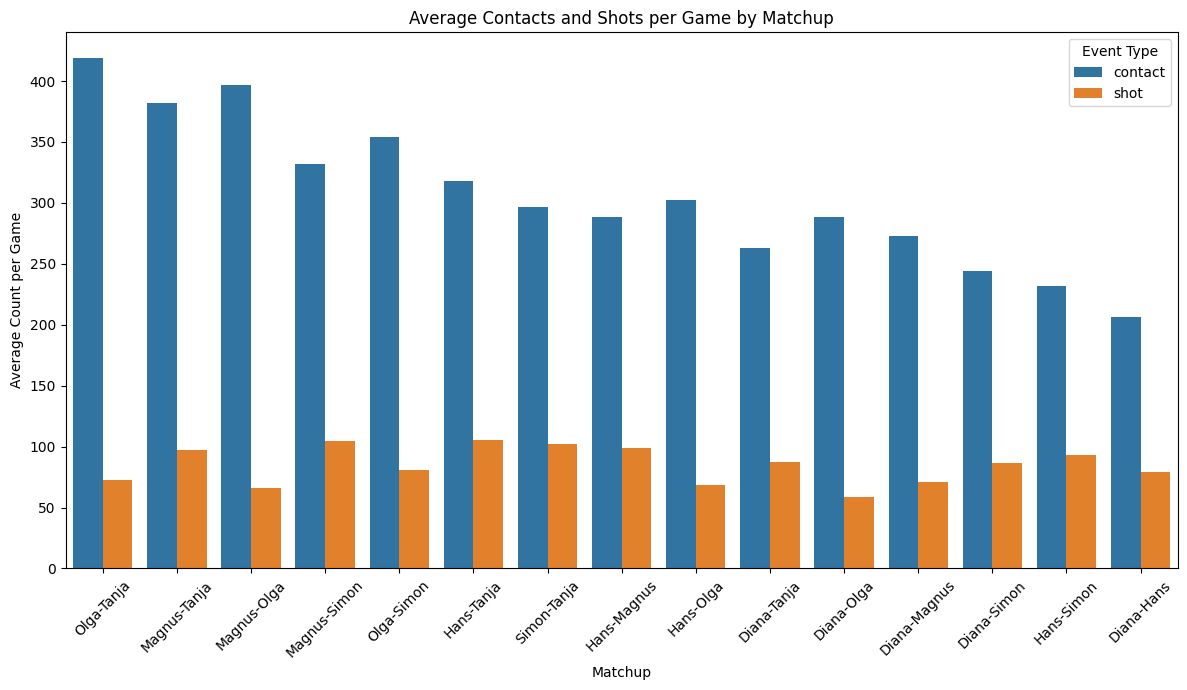

In [151]:
# Reshape data for plotting
plot_df = avg_counts.melt(
    id_vars="game",
    value_vars=["contact", "shot"],
    var_name="Event Type",
    value_name="Average Count per Game")

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_df,
    x="game",
    y="Average Count per Game",
    hue="Event Type")

# Axis labels
plt.xticks(rotation=45)
plt.title("Average Contacts and Shots per Game by Matchup")
plt.xlabel("Matchup")
plt.ylabel("Average Count per Game")
plt.tight_layout()
plt.show()

###  Shot Conversion

In [152]:
# Conversion rate is number of successful goals / shot.
timestamped_data['is_shot'] = timestamped_data['event_type'] == 'shot'

player_conversion_rate = timestamped_data.groupby('player').agg(shots=('is_shot','sum'), goals=('is_goal', 'sum')).reset_index()
player_conversion_rate['conversion_rate'] = (player_conversion_rate['goals'] / player_conversion_rate['shots'])


In [153]:
player_conversion_rate

,player,shots,goals,conversion_rate
0,Diana,944,240,0.254237
1,Hans,1247,162,0.129912
2,Magnus,1002,186,0.185629
3,Olga,664,223,0.335843
4,Simon,1368,219,0.160088
5,Tanja,1141,189,0.165644


Text(0.5, 1.0, 'Shot Conversion Rate for each player')

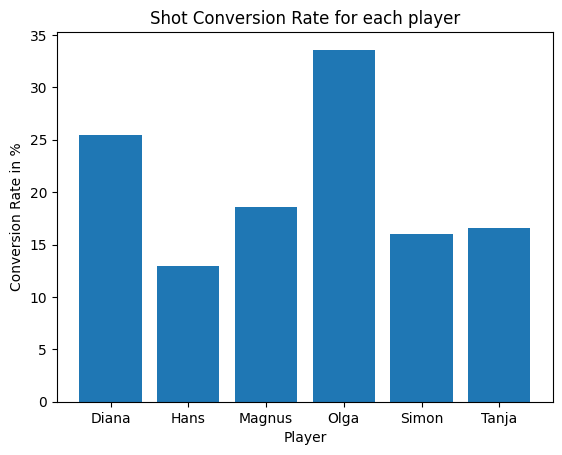

In [154]:
plt.figure()
plt.xlabel('Player')
plt.ylabel('Conversion Rate in %')
plt.bar(player_conversion_rate['player'], (player_conversion_rate['conversion_rate'] * 100))
plt.title('Shot Conversion Rate for each player')

### Round Duration by player shots? Does Longer Round = more shots taken?

Text(0.5, 1.0, 'Shorter Round = Less Shots ?')

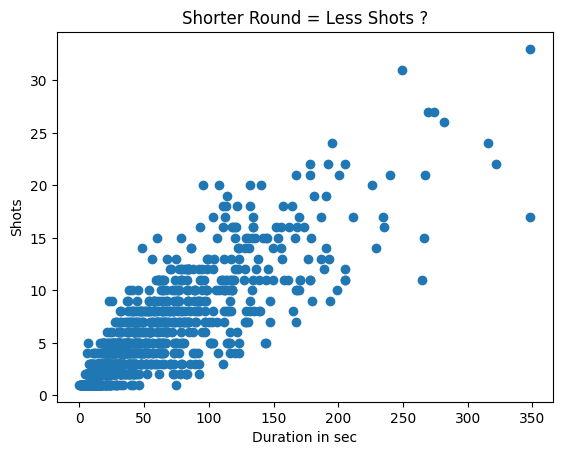

In [155]:
round_data['total_shots'] = (round_data['shots_p1'] + round_data['shots_p2'])
plt.scatter(round_data['duration'], round_data['total_shots'])
plt.xlabel('Duration in sec')
plt.ylabel("Shots")
plt.title('Shorter Round = Less Shots ?')

In [156]:
# Plotly Graph for the same...
fig = px.scatter(round_data, x='duration', y='total_shots', hover_data={'duration': True, 'player_1': True, 'player_2': True, 'total_shots': True, 'shots_p1': True, 'shots_p2': True},
                 title="Shot Duration", labels={'duration': 'Duration in sec'})
fig.show()

### Heatmaps

In [157]:
def plot_kicker_heatmap(matchup_names, df=None, ax=None):
    mask = (
        (df['game'] == matchup_names) & #filtering the data (no run_id -> all of the games for each matchup)
        (df['bar'].notna()) & 
        (df['side'].notna()) & 
        (df['event_type'] == 'contact') #only contacts 
    )

    game_data = df[mask].copy() #this is the df that gets used in this function

    p1name = game_data['player_1'].iloc[0] #extracting the player names
    p2name = game_data['player_2'].iloc[0]

    bar_order = ['Goal1', 'Defense1', 'Attack2', 'Middle1', 'Middle2', 'Attack1', 'Defense2', 'Goal2'] #order of the bars
    side_order = ['Left', 'Middle', 'Right'] #order of the sides

    counts = game_data.groupby(['bar', 'side']).size().unstack(fill_value=0) #counting how often each combination happens
    counts = counts.reindex(index=bar_order, columns=side_order, fill_value=0) #bringing it in the correct order
    
    total_actions = counts.values.sum() #summing up all of the values
    heatmap_percent = (counts / total_actions) * 100 #calculating in percent

    #for the y-axis labels: bars of player 1 on the left side, bars of player 2 on the right side
    left_labels = [b.replace('1', f' ({p1name})') if b.endswith('1') else '' for b in bar_order] #renaming e.g. "Attack1" to "Attack Diana" (player 1 name)
    right_labels = [b.replace('2', f' ({p2name})') if b.endswith('2') else '' for b in bar_order] #renaming for player 2 too

    if ax is None: #ax argument is for plotting multiple plots
        fig, ax = plt.subplots(figsize=(6, 8)) #if no ax provided -> just plotting for this one matchup

    sns.heatmap( #creating a heatmap
        heatmap_percent, 
        annot=True, 
        fmt=".1f", 
        cmap="Reds",
        linewidths=2, 
        linecolor='white',
        cbar=False,
        yticklabels=left_labels,
        ax=ax,
        vmin=0, 
        vmax=10 #10 percent is the maximum -> values above will have the same color
    )

    ax.set_yticklabels(left_labels, rotation=0, fontsize=9) #on the left side (y-axis) only the bars of player 1
    ax.set_xlabel("") #no "side" on the axis
    ax.set_ylabel("") #no "bar" on the axis

    ax2 = ax.twinx() #creating a second y-axis
    ax2.set_ylim(ax.get_ylim()) 
    ax2.set_yticks(ax.get_yticks()) #same height of the ticks
    ax2.set_yticklabels(right_labels, rotation=0, fontsize=9)
    ax2.set_ylabel("")

    ax.set_title(f"{matchup_names}\n({total_actions} actions, excluding goals)")
    ax.xaxis.tick_bottom()

    for t in ax.texts: #adds % signs
        if "%" not in t.get_text():
            t.set_text(t.get_text() + "%")

In [158]:
#plot_kicker_heatmap("Diana-Hans", timestamped_data)

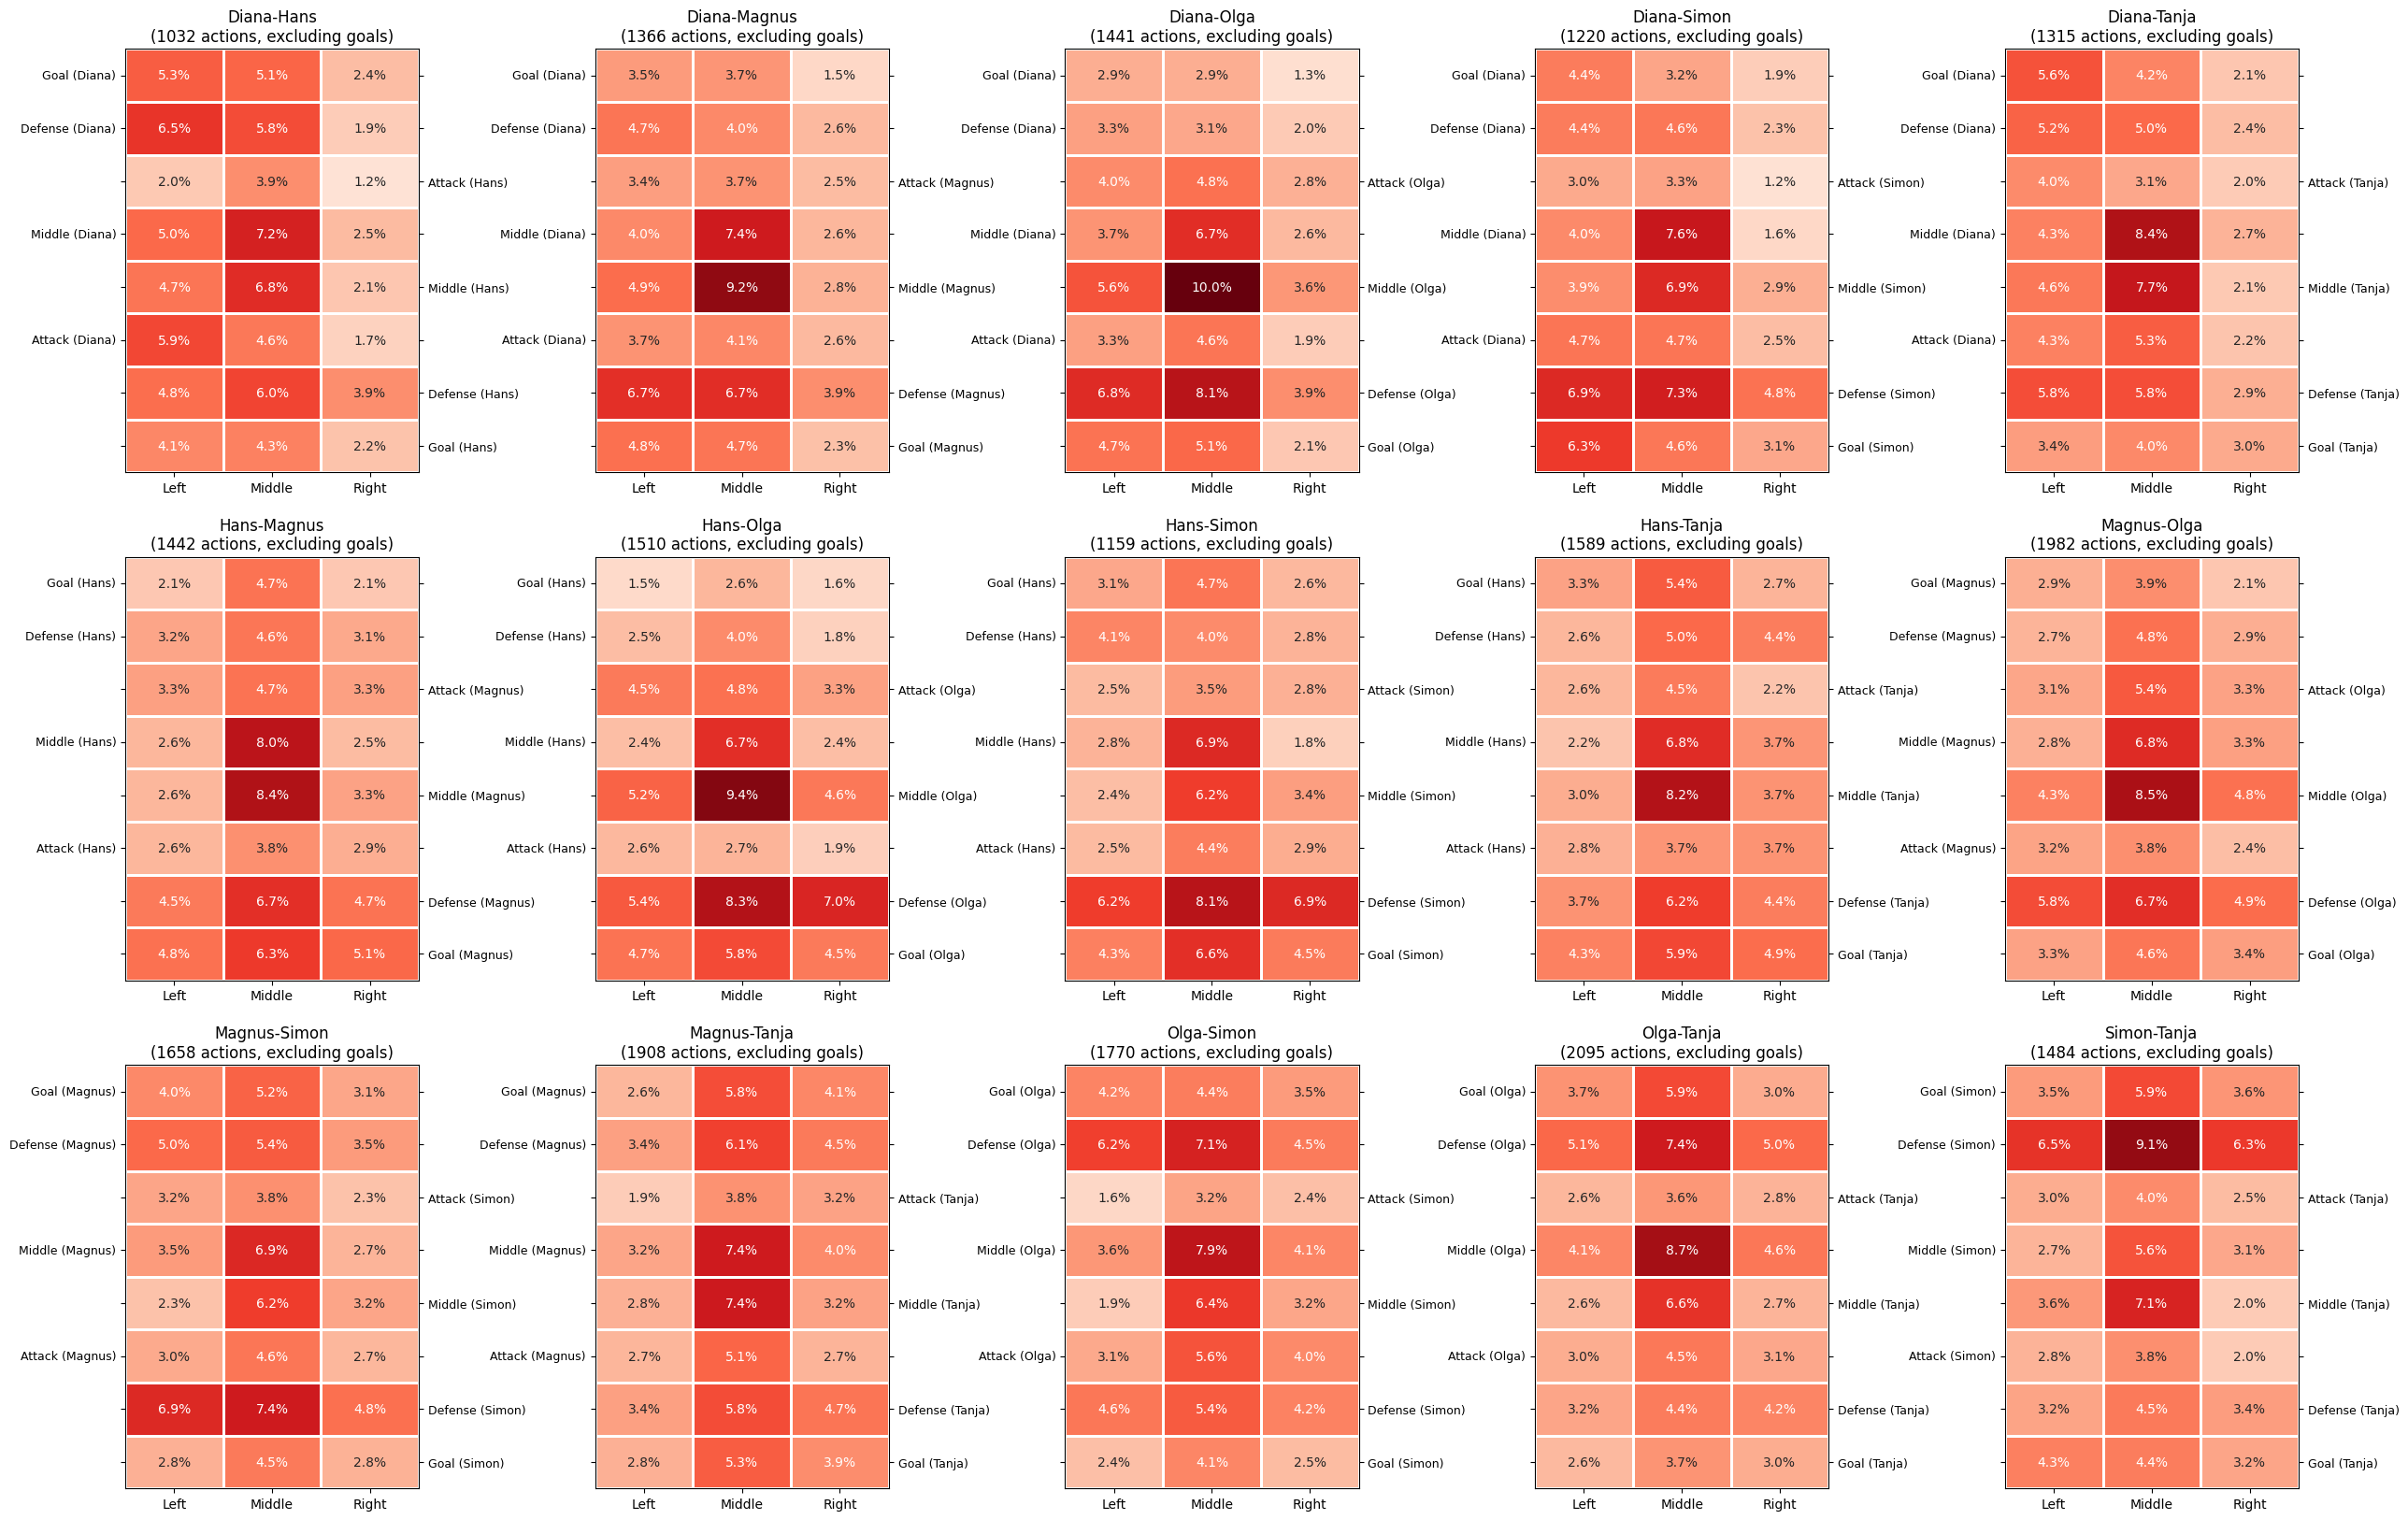

In [159]:
all_matchups = sorted(timestamped_data['game'].unique()) #finding all of the matchups (= "game" names)

fig, axes = plt.subplots(3, 5, figsize=(30, 20)) #3 rows, 5 columns
axes = axes.flatten()

for i, matchup in enumerate(all_matchups): #creating a plot for each matchup 
    plot_kicker_heatmap(matchup, df=timestamped_data, ax=axes[i]) #different ax for each plot -> used in the function

plt.subplots_adjust(hspace=0.2, wspace=0.6) #spaces between the plots
plt.show()

In [160]:
def plot_aggregated_player_profile(target_player, ax=None): #to aggregate the heatmap for a specific player
    mask = (timestamped_data['player_1'] == target_player) | (timestamped_data['player_2'] == target_player) #filtering for all of the games with that player
    player_data = timestamped_data[mask].copy() #using only games of that player
    
    def normalize_matchup(row): #the target player has to be player 1 in the plot -> changing that up when the target player is player 2
        if row['player_2'] == target_player:
            new_bar = row['bar']
            if pd.notna(new_bar):
                if '1' in new_bar: new_bar = new_bar.replace('1', '2') #replacing the bar names if the target player is player 2 e.g. "Attack1" -> "Attack2"
                elif '2' in new_bar: new_bar = new_bar.replace('2', '1') #e.g. "Attack2" -> "Attack1"
            
            return pd.Series([f"{target_player} vs Others", target_player, "Others", new_bar], #returns "new" data where the game name is "[target_player] vs Others"
                             index=['game', 'player_1', 'player_2', 'bar'])
        else:
            return pd.Series([f"{target_player} vs Others", target_player, "Others", row['bar']], 
                             index=['game', 'player_1', 'player_2', 'bar'])

    norm_cols = player_data.apply(normalize_matchup, axis=1) #applying the normalize function
    player_data[['game', 'player_1', 'player_2', 'bar']] = norm_cols #changing the df

    plot_kicker_heatmap(f"{target_player} vs Others", df=player_data, ax=ax) #using the previous function for the "[target_player] vs Others" games in the new df

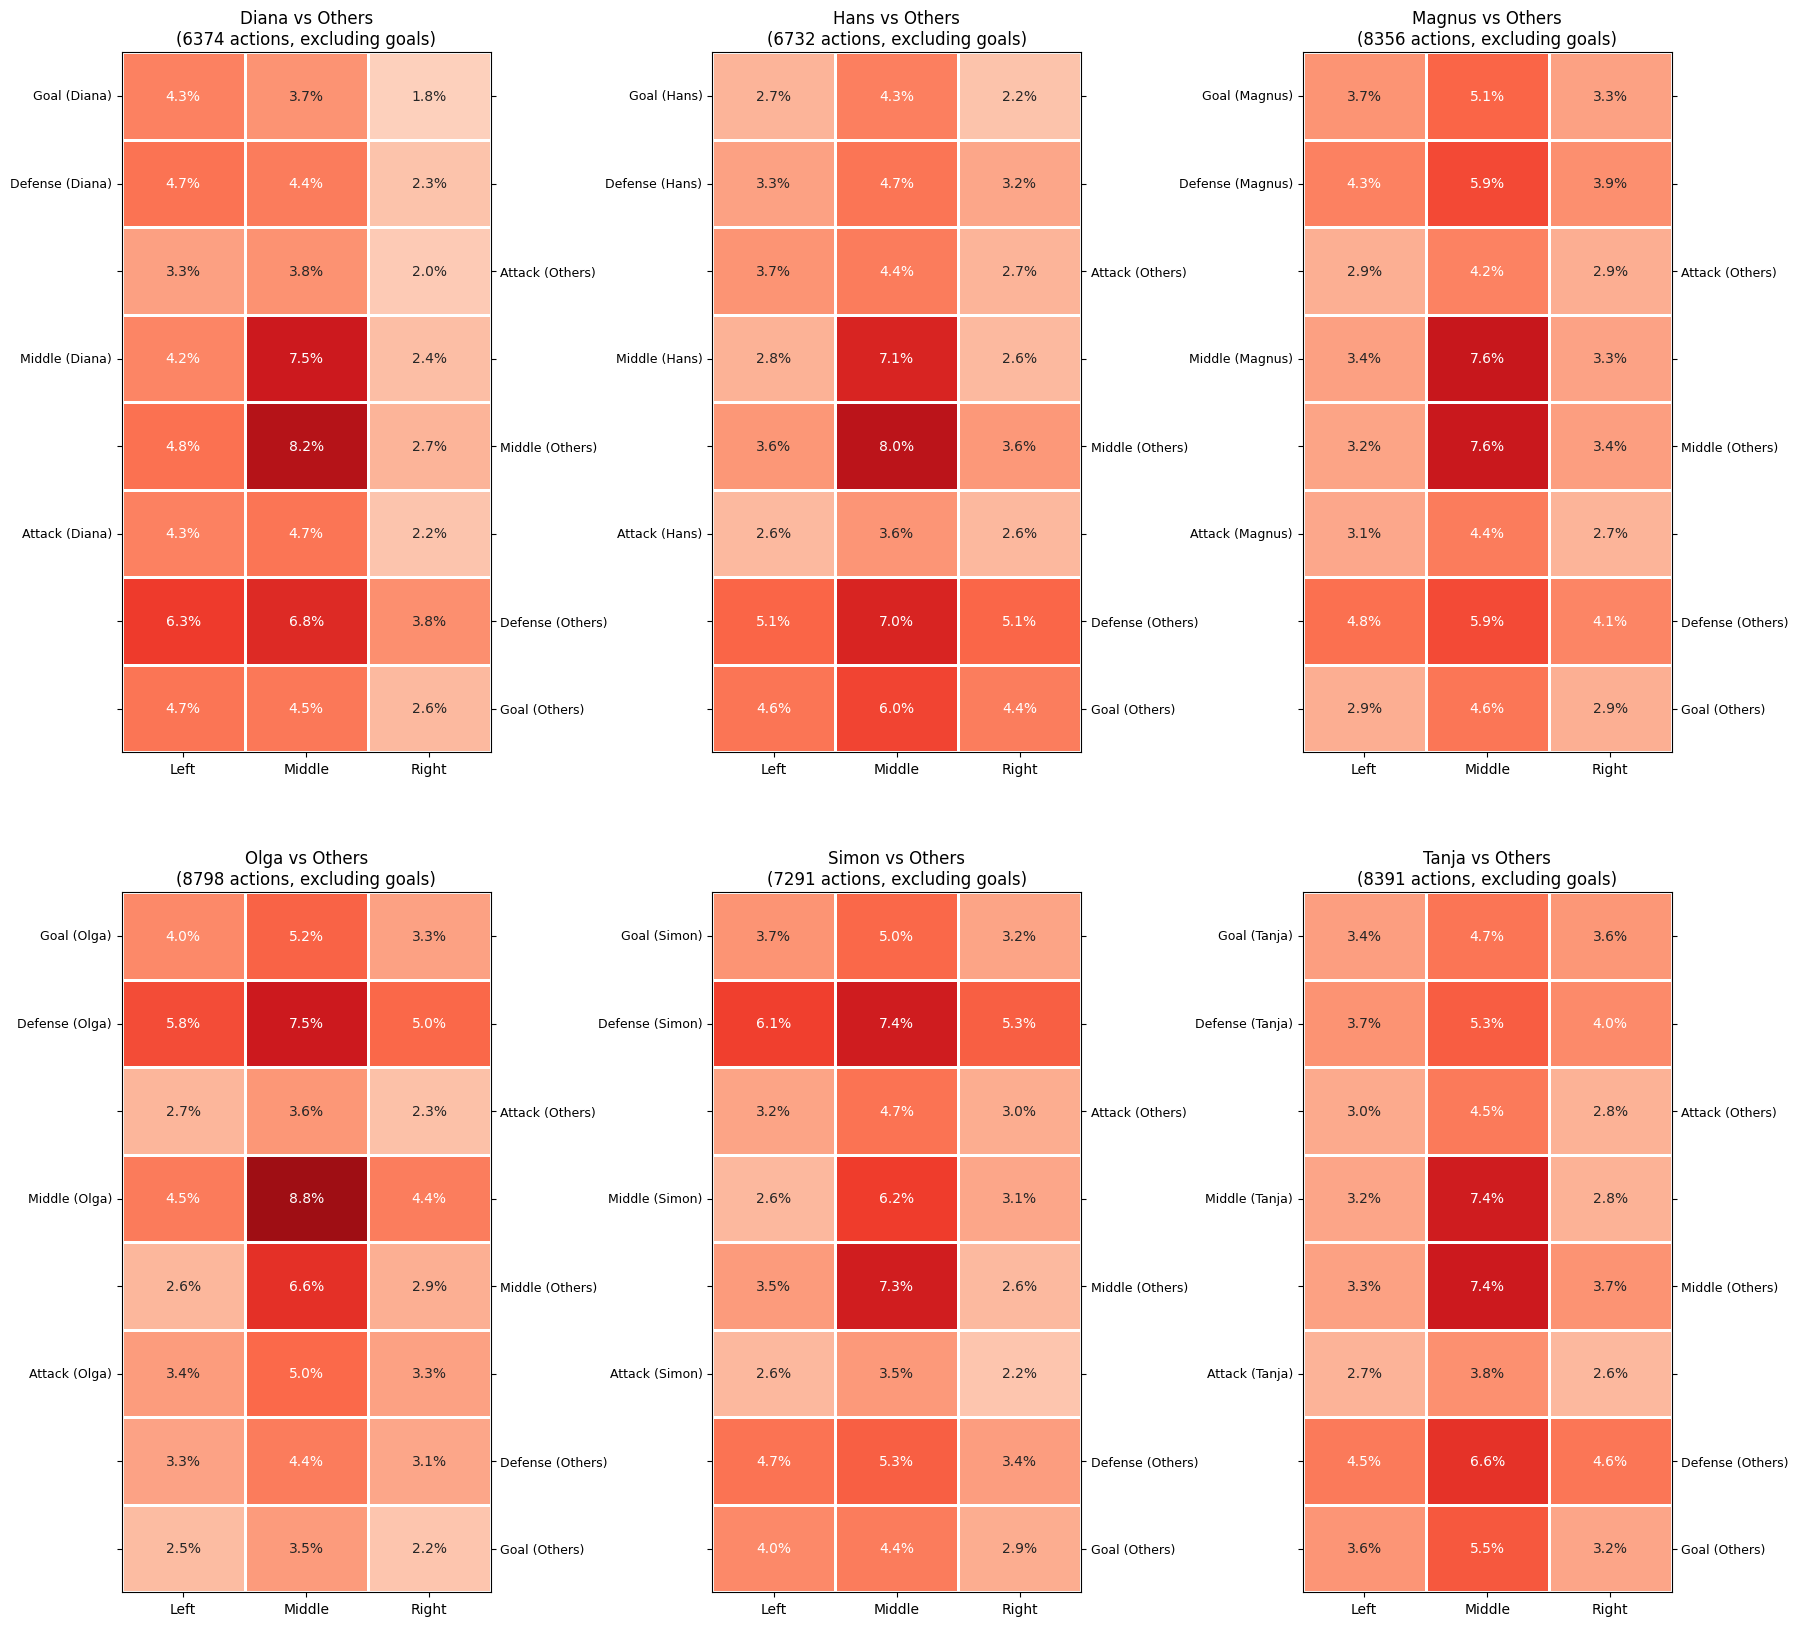

In [161]:
all_players = sorted(list(set(results_table['winner']) | set(results_table['loser']))) #list of all players

fig, axes = plt.subplots(2, 3, figsize=(20, 20)) #2 rows, 3 columns
axes_flat = axes.flatten()

for i, player in enumerate(sorted(all_players)): #creating the plot for each player
    plot_aggregated_player_profile(player, ax=axes_flat[i])

plt.subplots_adjust(wspace=0.6, hspace=0.2) #spaces between the plots
plt.show()

## Connecting goals to previous contacts

In [ ]:
timestamped_data['prev_player'] = timestamped_data.groupby(['game', 'run_id'])['player'].shift(1) #shift(1) -> taking the row above
timestamped_data['prev_bar'] = timestamped_data.groupby(['game', 'run_id'])['bar'].shift(1)
timestamped_data['prev_side'] = timestamped_data.groupby(['game', 'run_id'])['side'].shift(1)
timestamped_data['prev_event'] = timestamped_data.groupby(['game', 'run_id'])['event_type'].shift(1)

shot_events = timestamped_data[timestamped_data['event_type'] == 'shot'].copy()

shot_events = shot_events.drop(columns=['prev_event', 'bar', 'side', 'is_shot', 'is_shot_p1', 'is_shot_p2', 'is_contact_p1', 'is_contact_p2', 'round'])
shot_events.head()

,game,run_id,player_1,player_2,timestamp,player,event_type,is_goal,prev_player,prev_bar,prev_side
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,True,Hans,Attack2,Middle
6,Diana-Hans,0,Diana,Hans,23.388610,Diana,shot,False,Diana,Defense1,Left
9,Diana-Hans,0,Diana,Hans,33.182286,Hans,shot,False,Hans,Attack2,Middle
11,Diana-Hans,0,Diana,Hans,35.235728,Diana,shot,False,Diana,Defense1,Middle
16,Diana-Hans,0,Diana,Hans,50.007118,Hans,shot,False,Hans,Goal2,Left


In [192]:
successful_goals = shot_events[(shot_events['is_goal'])].copy()

unsuccessful_goals = shot_events[(shot_events['is_goal'] == False)].copy()

own_goals = shot_events[(shot_events['is_goal'] == True) & (shot_events['player'] != shot_events['prev_player'])].copy()

In [193]:
successful_goals.shape

(1219, 11)

In [194]:
unsuccessful_goals.shape

(5147, 11)

In [195]:
own_goals.shape #are there really no own goals?

(0, 11)

## Specific players

In [163]:
def timestamped_player_data(player_name):
    player_df = timestamped_data[(timestamped_data['player_1'] == player_name) | (timestamped_data['player_2'] == player_name)]
    return player_df

In [164]:
def results_player_data(player_name):
    player_df = results_table[(results_table['player_1'] == player_name) | (results_table['player_2'] == player_name)]
    return player_df

In [165]:
def round_player_data(player_name):
    player_df = round_data[(round_data['player_1'] == player_name) | (round_data['player_2'] == player_name)]
    return player_df

In [211]:
def shot_events_player_data(player_name):
    player_df = shot_events[(shot_events['player'] == player_name)]
    return player_df

In [166]:
def get_average_points(df, player_name):
    points_as_p1 = df.loc[df['player_1'] == player_name, 'points_player_1']
    points_as_p2 = df.loc[df['player_2'] == player_name, 'points_player_2']
    all_points = pd.concat([points_as_p1, points_as_p2])
    return all_points.mean()

In [167]:
def plot_player_performance(df, player_name):
    p1_mask = df['player_1'] == player_name
    case_p1 = df[p1_mask][['points_p1', 'points_p2']].rename(columns={'points_p1': 'player_p', 'points_p2': 'opponent_p'}) #when the player is player 1
    
    p2_mask = df['player_2'] == player_name
    case_p2 = df[p2_mask][['points_p2', 'points_p1']].rename(columns={'points_p2': 'player_p', 'points_p1': 'opponent_p'}) #when the player is player 2
    
    combined = pd.concat([case_p1, case_p2]) #combining both cases
    
    stats = combined.groupby('opponent_p')['player_p'].agg(['mean', 'min', 'max', 'count']).reset_index()
    
    plt.figure(figsize=(10, 5))
    
    plt.fill_between(stats['opponent_p'], #for the shadowed part around the mean line 
                     stats['min'], #the minimum player points for the amount of opponent points
                     stats['max'], #the maximum player points for the amount of opponent points
                     alpha = 0.2) #amount of transparency

    plt.plot(stats['opponent_p'], stats['mean']) #the mean line
    
    new_labels = [f"{int(row['opponent_p'])}\n(n={int(row['count'])})" for _, row in stats.iterrows()] #adding how many rows it counted 
    plt.xticks(stats['opponent_p'], new_labels)
    
    plt.title(f"Average points of {player_name} (incl. min and max) against opponent's points")
    plt.xlabel("Opponent's points")
    plt.ylabel(f"Points of {player_name}")
    plt.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

In [244]:
def plot_shot_heatmap(df, player_name, successful=True):
    if successful:
        plot_data = df[df['is_goal'] == True].copy() #only successful shots
        title_type = "Successful shots (goals)"
    else:
        plot_data = df[df['is_goal'] == False].copy() #only unsuccessful shots
        title_type = "Unsuccessful shots"
    
    plot_data['bar_clean'] = plot_data['prev_bar'].str.replace(r'\d+', '', regex=True) #removes "1" or "2" at the end of the bar name
    
    bar_order = ['Attack', 'Middle', 'Defense', 'Goal']
    side_order = ['Left', 'Middle', 'Right']
    
    counts = plot_data.groupby(['bar_clean', 'prev_side']).size().unstack(fill_value=0)
    heatmap_data = counts.reindex(index=bar_order, columns=side_order, fill_value=0)
    
    total_shots = heatmap_data.values.sum()
    heatmap_percent = (heatmap_data / total_shots) * 100

    plt.figure(figsize=(7, 4))
    sns.heatmap(
        heatmap_percent, 
        annot=True, 
        fmt=".1f",
        cbar=False, 
        cmap="Reds",
        linewidths=1.5,
        linecolor='white')
    
    plt.title(f"{title_type}: {player_name}\n({int(total_shots)} shots total)", pad=15)
    plt.xlabel("")
    plt.ylabel("")

    for t in plt.gca().texts:
        t.set_text(t.get_text() + "%")
    
    plt.gca().xaxis.tick_top()
    plt.gca().xaxis.set_label_position('top')
    
    plt.tight_layout()
    plt.show()

### Diana - 22 games won

In [245]:
timestamped_data_diana = timestamped_player_data('Diana')
results_data_diana = results_player_data('Diana')
round_data_diana = round_player_data('Diana')
shot_events_diana = shot_events_player_data('Diana')

In [246]:
results_data_diana

,game,run_id,player_1,player_2,points_player_1,points_player_2,winner,loser
0,Diana-Hans,0,Diana,Hans,10,5,Diana,Hans
1,Diana-Hans,1,Diana,Hans,10,5,Diana,Hans
2,Diana-Hans,2,Diana,Hans,10,5,Diana,Hans
3,Diana-Hans,3,Diana,Hans,10,4,Diana,Hans
4,Diana-Hans,4,Diana,Hans,10,5,Diana,Hans
5,Diana-Magnus,0,Diana,Magnus,5,10,Magnus,Diana
6,Diana-Magnus,1,Diana,Magnus,10,4,Diana,Magnus
7,Diana-Magnus,2,Diana,Magnus,10,5,Diana,Magnus
8,Diana-Magnus,3,Diana,Magnus,10,7,Diana,Magnus
9,Diana-Magnus,4,Diana,Magnus,10,7,Diana,Magnus


In the games Diana lost, she achieved 5, 7 and 8 points. Her best game was run 3 against Simon (10-2) and her worst game was run 0 against Magnus (5-10). 

In [247]:
print(get_average_points(results_data_diana, 'Diana'))

9.6


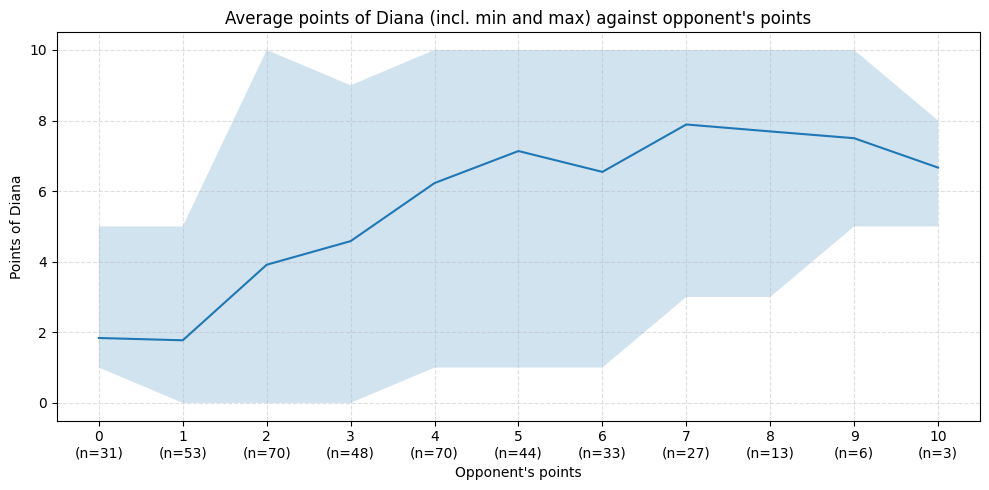

In [248]:
plot_player_performance(round_data_diana, 'Diana')

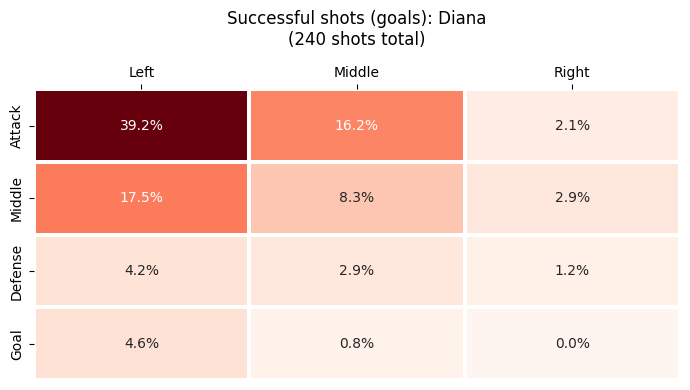

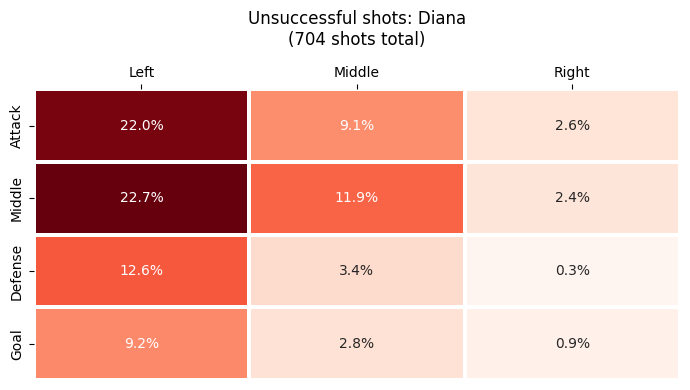

In [249]:
plot_shot_heatmap(shot_events_diana, "Diana")
plot_shot_heatmap(shot_events_diana, "Diana", successful=False)

### Simon - 17 games won

In [250]:
timestamped_data_simon = timestamped_player_data('Simon')
results_data_simon = results_player_data('Simon')
round_data_simon = round_player_data('Simon')
shot_events_simon = shot_events_player_data('Simon')

In [251]:
print(get_average_points(results_data_simon, 'Simon'))

8.76


### Olga - 15 games won

In [174]:
timestamped_data_olga = timestamped_player_data('Olga')
results_data_olga = results_player_data('Olga')
round_data_olga = round_player_data('Olga')

In [175]:
print(get_average_points(results_data_olga, 'Olga'))

8.92


### Magnus - 10 games won

In [ ]:
timestamped_data_magnus = timestamped_player_data('Magnus')
results_data_magnus = results_player_data('Magnus')
round_data_magnus = round_player_data('Magnus')
shot_events_magnus = shot_events_player_data('Magnus')

In [177]:
print(get_average_points(results_data_magnus, 'Magnus'))

7.44


### Tanja - 8 games won

In [ ]:
timestamped_data_tanja = timestamped_player_data('Tanja')
results_data_tanja = results_player_data('Tanja')
round_data_tanja = round_player_data('Tanja')
shot_events_tanja = shot_events_player_data('Tanja')

In [179]:
print(get_average_points(results_data_tanja, 'Tanja'))

7.56


### Hans - 3 games won

In [242]:
timestamped_data_hans = timestamped_player_data('Hans')
results_data_hans = results_player_data('Hans')
round_data_hans = round_player_data('Hans')
shot_events_hans = shot_events_player_data('Hans')

In [181]:
results_data_hans

,game,run_id,player_1,player_2,points_player_1,points_player_2,winner,loser
0,Diana-Hans,0,Diana,Hans,10,5,Diana,Hans
1,Diana-Hans,1,Diana,Hans,10,5,Diana,Hans
2,Diana-Hans,2,Diana,Hans,10,5,Diana,Hans
3,Diana-Hans,3,Diana,Hans,10,4,Diana,Hans
4,Diana-Hans,4,Diana,Hans,10,5,Diana,Hans
25,Hans-Magnus,0,Hans,Magnus,7,10,Magnus,Hans
26,Hans-Magnus,1,Hans,Magnus,6,10,Magnus,Hans
27,Hans-Magnus,2,Hans,Magnus,8,10,Magnus,Hans
28,Hans-Magnus,3,Hans,Magnus,9,10,Magnus,Hans
29,Hans-Magnus,4,Hans,Magnus,5,10,Magnus,Hans


Hans' best game was run 0 against Tanja (10-8) and his worst games were run 3 against Olga (3-10) and run 1 against Hans (3-10).

In [182]:
print(get_average_points(results_data_hans, 'Hans'))

6.48


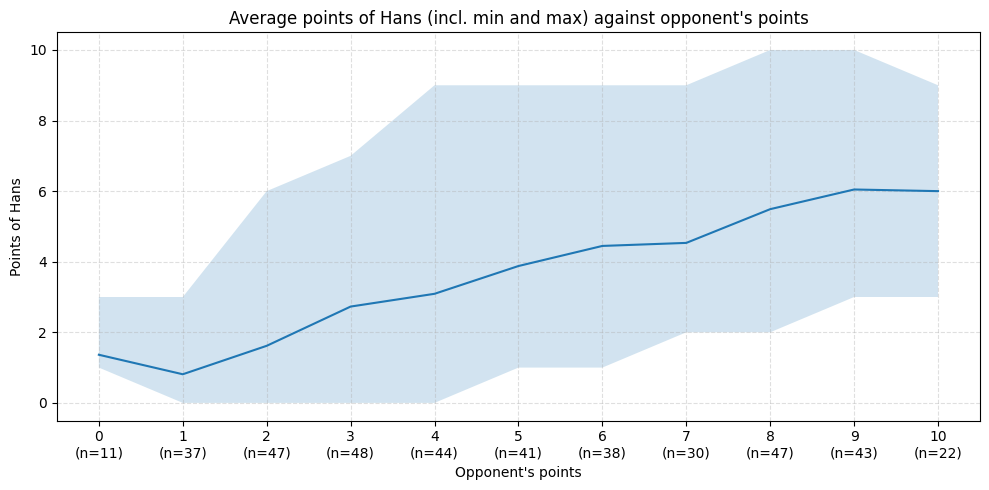

In [183]:
plot_player_performance(round_data_hans, 'Hans')

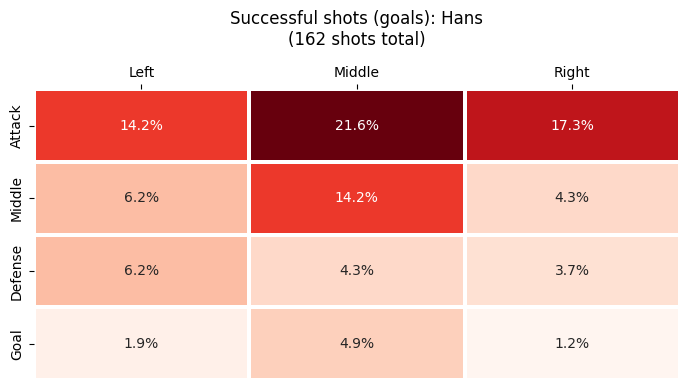

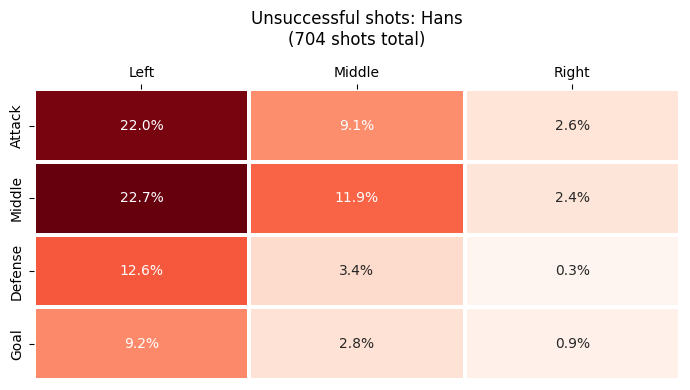

In [243]:
plot_shot_heatmap(shot_events_hans, 'Hans')
plot_shot_heatmap(shot_events_diana, 'Hans', successful=False)